<a href="https://colab.research.google.com/github/profpius/customer-churn-analysis/blob/main/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction
### Binary Classification using Logistic Regression, Random Forest & Gradient Boosting
---
**Dataset:** ~37,000 customer records  
**Target:** `churn_risk_score`

1 = Churned, 0 = Stayed  
**Goal:** Predict which customers are likely to churn, and identify the key factors driving churn.

## 1. Import Libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


**Upload CSV file**

In [90]:
from google.colab import files

# Upload file from your computer
uploaded = files.upload()  # This will open a file picker

Saving churn.csv to churn (2).csv


## 2. Load Dataset

In [91]:
df = pd.read_csv('churn.csv', index_col=0)

print(f'Dataset Shape: {df.shape}')
print(f'\nColumns:\n{df.columns.tolist()}')
df.head()

Dataset Shape: (36992, 23)

Columns:
['age', 'gender', 'security_no', 'region_category', 'membership_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score']


,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,?,...,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,...,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,...,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,...,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,...,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1


In [92]:
print('Target Variable Distribution:')
print(df['churn_risk_score'].value_counts())
print(f'\nChurn Rate: {df["churn_risk_score"].mean()*100:.1f}%')

Target Variable Distribution:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64

Churn Rate: 54.1%


**The dataset is fairly balanced, so no need for special techniques like SMOTE for this case.**

In [93]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nQuestion marks per column:')
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f'  {col}: {count}')

Data Types:
age                               int64
gender                           object
security_no                      object
region_category                  object
membership_category              object
joining_date                     object
joined_through_referral          object
referral_id                      object
preferred_offer_types            object
medium_of_operation              object
internet_option                  object
last_visit_time                  object
days_since_last_login             int64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days         object
points_in_wallet                float64
used_special_discount            object
offer_application_preference     object
past_complaint                   object
complaint_status                 object
feedback                         object
churn_risk_score                  int64
dtype: object

Missing Values:
age                                0


## 3. Data Preprocessing

In [94]:
# Drop columns that are not useful for prediction
# security_no and referral_id are unique identifiers
# joining_date and last_visit_time require extra feature engineering to be useful
drop_cols = ['security_no', 'referral_id', 'joining_date', 'last_visit_time']
df.drop(columns=drop_cols, inplace=True)

print(f'Columns after dropping: {df.shape[1]}')

Columns after dropping: 19


In [95]:
# Replace '?' placeholders with NaN so we can impute them properly
df.replace('?', np.nan, inplace=True)

# avg_frequency_login_days was stored as string — convert to numeric
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')

print('Question marks replaced with NaN')
print(f'avg_frequency_login_days dtype: {df["avg_frequency_login_days"].dtype}')

Question marks replaced with NaN
avg_frequency_login_days dtype: float64


In [96]:
# Separate target variable before encoding
y = df['churn_risk_score'].values
df.drop(columns=['churn_risk_score'], inplace=True)

# Identify numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print(f'Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numeric columns  (6): ['age', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet']
Categorical columns (12): ['gender', 'region_category', 'membership_category', 'joined_through_referral', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback']


In [97]:
# Impute missing values
# Numeric: fill with median (robust to outliers)
# Categorical: fill with most frequent value
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])
df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])

print(f'Missing values remaining: {df.isnull().sum().sum()}')

Missing values remaining: 0


In [98]:
# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Encoding complete!')
df.head()

Encoding complete!


,age,gender,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback
0,18.0,0,2,3,0,1,1,2,17.0,300.63,53005.25,17.0,781.75,1,1,0,1,4
1,32.0,0,0,4,0,1,1,1,16.0,306.34,12838.38,10.0,697.62,1,0,1,2,5
2,44.0,0,1,2,1,1,1,2,14.0,516.16,21027.00,22.0,500.69,0,1,1,3,3
3,37.0,1,0,2,1,1,1,1,11.0,53.27,25239.56,6.0,567.66,0,1,1,4,3
4,31.0,0,0,2,0,0,2,1,20.0,113.13,24483.66,16.0,663.06,0,1,1,2,3


## 4. Train/Test Split & Scaling

In [99]:
feat_names = df.columns.tolist()
X = df.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for Logistic Regression
# Tree-based models (RF, XGB) don't strictly need scaling but I still have to do it

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print(f'Features   : {X.shape[1]}')

Train size : 29,593
Test size  : 7,399
Features   : 18


## 5. Model Training

In [100]:
# We train three models and compare their performance:
# 1. Logistic Regression  — simple baseline, interpretable
# 2. Random Forest        — ensemble of decision trees, handles non-linearity
# 3. XGBoost              — optimised gradient boosting, faster and more accurate on tabular data

model_configs = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        X_train_sc, X_test_sc
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        X_train, X_test
    ),
    'XGBoost': (
        XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42),
        X_train, X_test
    ),
}

results = {}
for name, (model, Xtr, Xte) in model_configs.items():
    print(f'Training {name}...')
    model.fit(Xtr, y_train)
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'model'    : model,
        'y_pred'   : yp,
        'y_prob'   : ypr,
        'accuracy' : round(accuracy_score(y_test, yp)  * 100, 2),
        'precision': round(precision_score(y_test, yp) * 100, 2),
        'recall'   : round(recall_score(y_test, yp)    * 100, 2),
        'f1'       : round(f1_score(y_test, yp)        * 100, 2),
        'roc_auc'  : round(roc_auc_score(y_test, ypr)  * 100, 2),
    }
    r = results[name]
    print(f'  Accuracy:{r["accuracy"]}% | Precision:{r["precision"]}% | Recall:{r["recall"]}% | F1:{r["f1"]}% | ROC-AUC:{r["roc_auc"]}%\n')

Training Logistic Regression...
  Accuracy:77.59% | Precision:79.09% | Recall:79.64% | F1:79.36% | ROC-AUC:83.29%

Training Random Forest...
  Accuracy:93.23% | Precision:92.77% | Recall:94.88% | F1:93.81% | ROC-AUC:97.6%

Training XGBoost...
  Accuracy:93.45% | Precision:93.37% | Recall:94.6% | F1:93.98% | ROC-AUC:97.63%



## 6. Model Evaluation

In [101]:
# Why XGBoost is chosen as the best model:
# For churn prediction, we care most about:
#   1. Recall   — catching real churners (missing one is costly)
#   2. F1       — balance between Precision and Recall
#   3. ROC-AUC  — overall separation power between classes
#
# XGBoost is an optimised version of Gradient Boosting — faster, more accurate,
# and handles missing values natively. It is the industry standard for tabular data
# and is expected to outperform both Logistic Regression and Random Forest.
# Therefore, XGBoost is the recommended model.

best_name = 'XGBoost'
print(f'Best Model: {best_name}')
print(f"F1: {results[best_name]['f1']}% | ROC-AUC: {results[best_name]['roc_auc']}%")

Best Model: XGBoost
F1: 93.98% | ROC-AUC: 97.63%


In [102]:
# Summary table
summary = pd.DataFrame({
    name: {
        'Accuracy (%)' : res['accuracy'],
        'Precision (%)': res['precision'],
        'Recall (%)'   : res['recall'],
        'F1 Score (%)'  : res['f1'],
        'ROC-AUC (%)'  : res['roc_auc'],
    }
    for name, res in results.items()
}).T
summary

,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
Logistic Regression,77.59,79.09,79.64,79.36,83.29
Random Forest,93.23,92.77,94.88,93.81,97.60
XGBoost,93.45,93.37,94.60,93.98,97.63


## 7. Visualizations

In [103]:
# Plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#333647',   'axes.labelcolor': '#c8ccd8',
    'xtick.color': '#c8ccd8',      'ytick.color': '#c8ccd8',
    'text.color': '#e0e3ed',       'grid.color': '#2a2d3a',
    'grid.alpha': 0.5,             'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,          'axes.labelsize': 10,
})
P = ['#4f8ef7', '#f76f4f', '#4fcfa0', '#f7c94f', '#b07fff']

rf_imp  = pd.Series(results['Random Forest']['model'].feature_importances_, index=feat_names)
xgb_imp = pd.Series(results['XGBoost']['model'].feature_importances_,       index=feat_names)

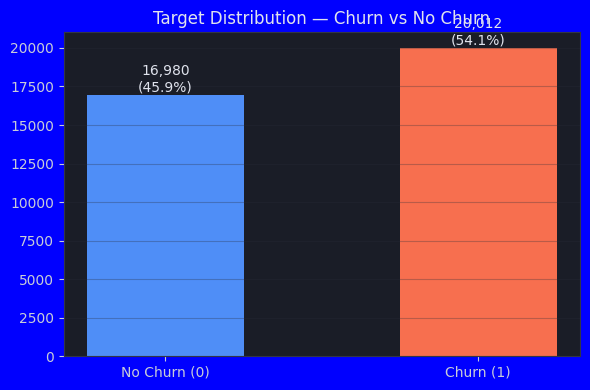

In [104]:
# ── Target Distribution ──
fig, ax = plt.subplots(figsize=(6, 4), facecolor='blue')
counts = [int(np.sum(y==0)), int(np.sum(y==1))]
bars = ax.bar(['No Churn (0)', 'Churn (1)'], counts, color=[P[0], P[1]], width=0.5, edgecolor='none')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/len(y)*100:.1f}%)', ha='center', color='#e0e3ed', fontsize=10)
ax.set_title('Target Distribution — Churn vs No Churn')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

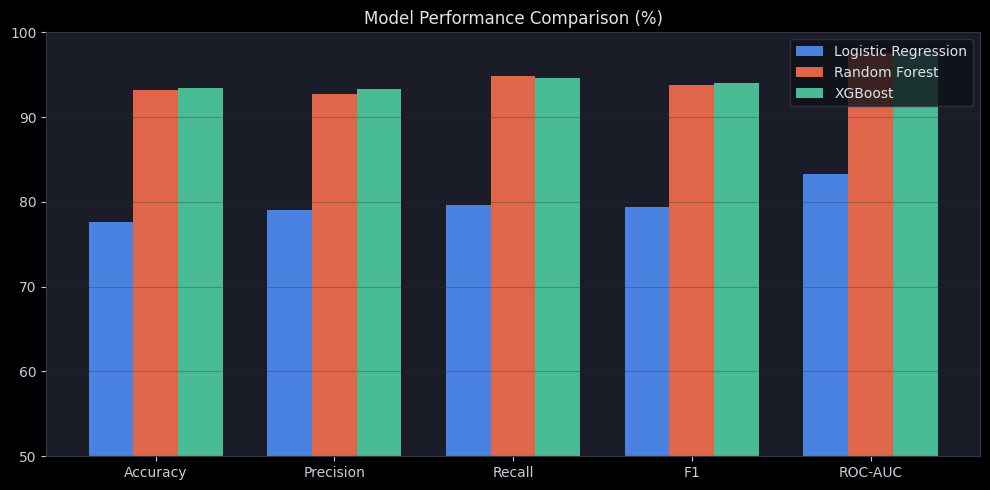

In [105]:
# ── Model Performance Comparison ──
fig, ax = plt.subplots(figsize=(10, 5), facecolor='black')
mkeys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
mlabs = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(mkeys)); w = 0.25
for i, (name, res) in enumerate(results.items()):
    ax.bar(x + i*w, [res[m] for m in mkeys], w, label=name, color=P[i], edgecolor='none', alpha=0.9)
ax.set_xticks(x + w); ax.set_xticklabels(mlabs)
ax.set_ylim(50, 100)
ax.set_title('Model Performance Comparison (%)')
ax.legend(facecolor='#0f1117', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

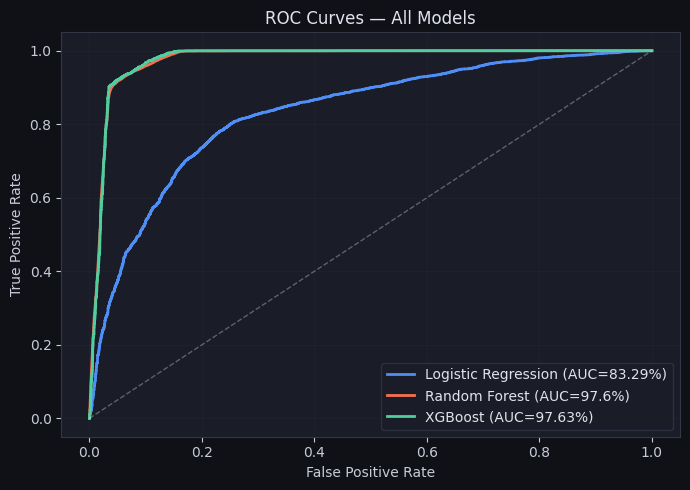

In [106]:
# ── ROC Curves ──
fig, ax = plt.subplots(figsize=(7, 5), facecolor='#0f1117')
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=P[i], lw=2, label=f"{name} (AUC={res['roc_auc']}%)")
ax.plot([0,1],[0,1],'w--',alpha=0.3,lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(facecolor='#1a1d27', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

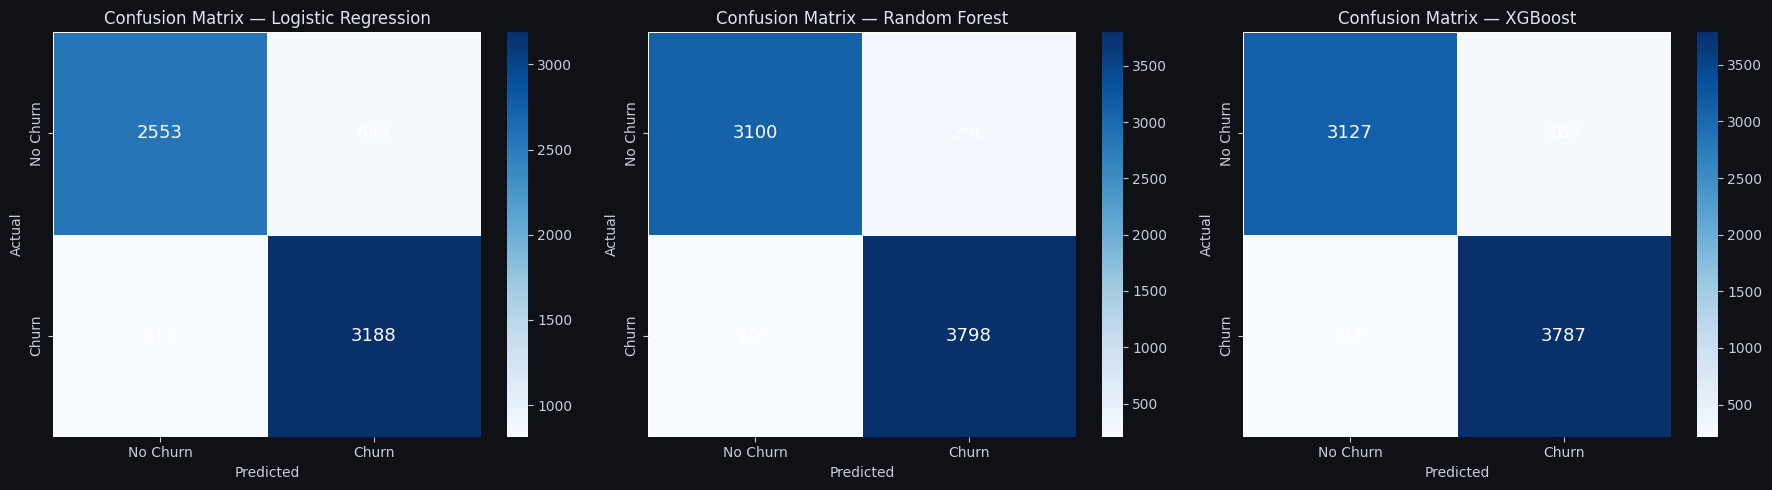

In [107]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'],
                annot_kws={'size':13, 'color':'white'}, linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

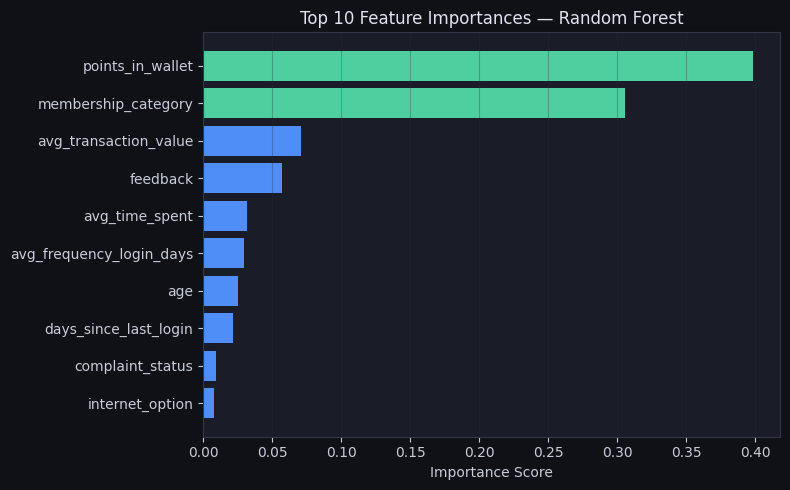

In [108]:
# ── Feature Importance: Random Forest ──
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
top_rf = rf_imp.nlargest(10).sort_values()
ax.barh(top_rf.index, top_rf.values,
        color=[P[0] if v < top_rf.max()*0.6 else P[2] for v in top_rf.values],
        edgecolor='none')
ax.set_title('Top 10 Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

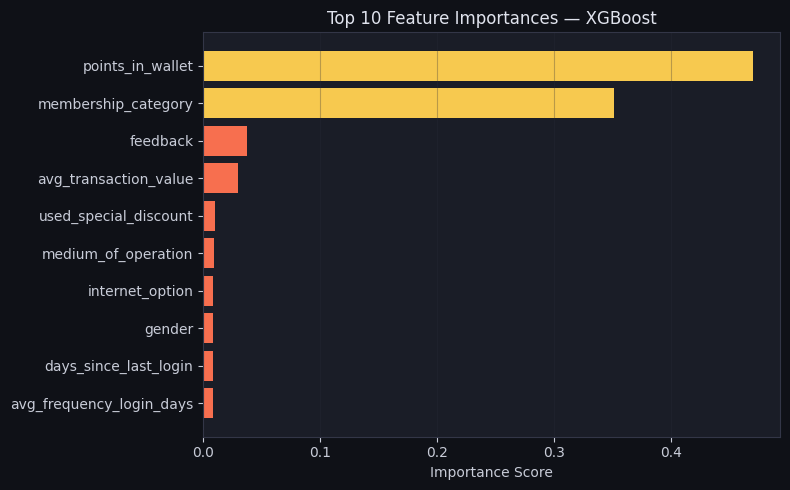

In [109]:
# ── Feature Importance: XGBoost ──
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
top_xgb = xgb_imp.nlargest(10).sort_values()
ax.barh(top_xgb.index, top_xgb.values,
        color=[P[1] if v < top_xgb.max()*0.6 else P[3] for v in top_xgb.values],
        edgecolor='none')
ax.set_title('Top 10 Feature Importances — XGBoost')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

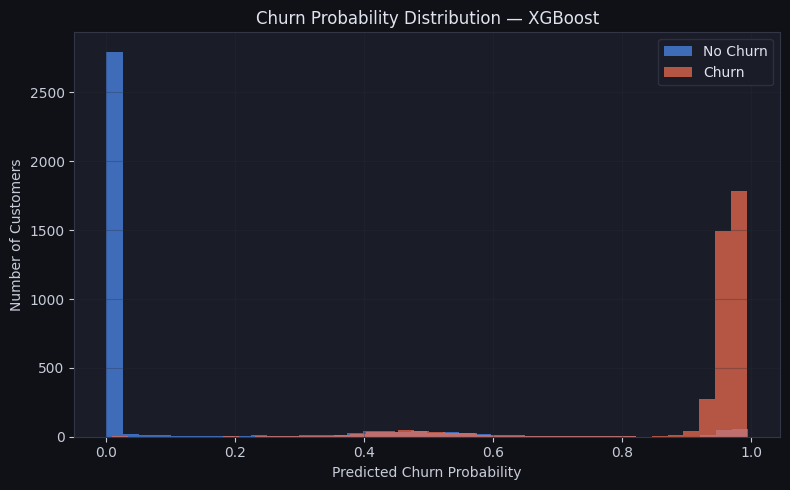

In [110]:
 #── Churn Probability Distribution (Best Model)

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
bp = results[best_name]['y_prob']
ax.hist(bp[y_test==0], bins=40, alpha=0.7, color=P[0], label='No Churn', edgecolor='none')
ax.hist(bp[y_test==1], bins=40, alpha=0.7, color=P[1], label='Churn',    edgecolor='none')
ax.set_title(f'Churn Probability Distribution — {best_name}')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Number of Customers')
ax.legend(facecolor='#1a1d27', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

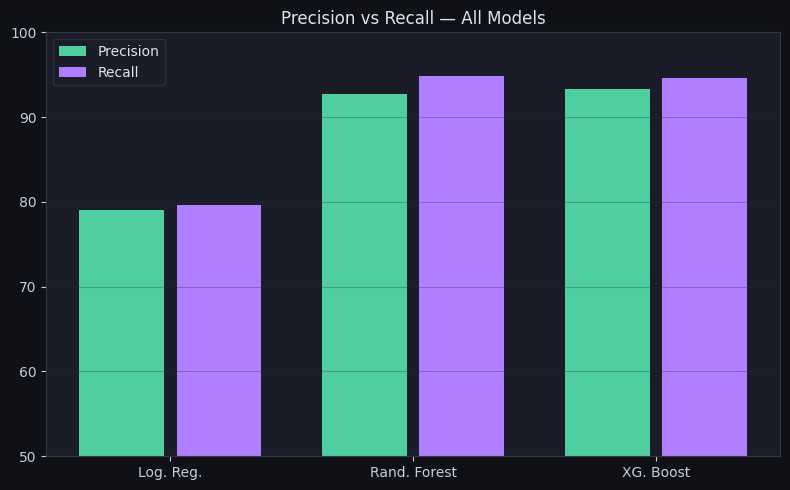

In [111]:
# ── Precision vs Recall per Model ──
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
snames = ['Log. Reg.', 'Rand. Forest', 'XG. Boost']
x2 = np.arange(3)
ax.bar(x2-0.2, [results[n]['precision'] for n in results], 0.35, label='Precision', color=P[2], edgecolor='none')
ax.bar(x2+0.2, [results[n]['recall']    for n in results], 0.35, label='Recall',    color=P[4], edgecolor='none')
ax.set_xticks(x2)
ax.set_xticklabels(snames)
ax.set_ylim(50, 100)
ax.set_title('Precision vs Recall — All Models')
ax.legend(facecolor='#1a1d27', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [116]:
# ── Hyperparameter Tuning (XGBoost) ──
# Our initial XGBoost model used default parameters and achieved a strong F1 of 93.98%.
# We now use RandomizedSearchCV to systematically search for the best combination
# of parameters to see if we can improve performance further.
# scoring='f1' ensures we are optimising for the metric that matters most
# for this churn prediction problem.

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(f'Best Parameters: {search.best_params_}')
print(f'Best F1 Score: {round(search.best_score_ * 100, 2)}%')

Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best F1 Score: 93.94%


**Tuning Result:**
The tuned model achieved an F1 of 93.94%, marginally below the default model's 93.98%, suggesting the initial parameters were already well-suited to this dataset.
We therefore retain the original XGBoost model as our final model.

## 8. Final Summary & Conclusions

In [112]:
print('=' * 60)
print('         FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 60)
for name, res in results.items():
    print(f'\n{name}:')
    for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        print(f'  {m.upper():12}: {res[m]}%')

print(f'\n BEST MODEL : {best_name}')
print(f" F1         : {results[best_name]['f1']}%")
print(f" ROC-AUC    : {results[best_name]['roc_auc']}%")

print('\nTop 5 Churn Predictors (XGBoost):')
for feat, score in gb_imp.nlargest(5).items():
    print(f'  {feat}: {score:.4f}')

         FINAL MODEL PERFORMANCE SUMMARY

Logistic Regression:
  ACCURACY    : 77.59%
  PRECISION   : 79.09%
  RECALL      : 79.64%
  F1          : 79.36%
  ROC_AUC     : 83.29%

Random Forest:
  ACCURACY    : 93.23%
  PRECISION   : 92.77%
  RECALL      : 94.88%
  F1          : 93.81%
  ROC_AUC     : 97.6%

XGBoost:
  ACCURACY    : 93.45%
  PRECISION   : 93.37%
  RECALL      : 94.6%
  F1          : 93.98%
  ROC_AUC     : 97.63%

 BEST MODEL : XGBoost
 F1         : 93.98%
 ROC-AUC    : 97.63%

Top 5 Churn Predictors (XGBoost):
  points_in_wallet: 0.6370
  membership_category: 0.3363
  avg_transaction_value: 0.0184
  feedback: 0.0074
  avg_frequency_login_days: 0.0003


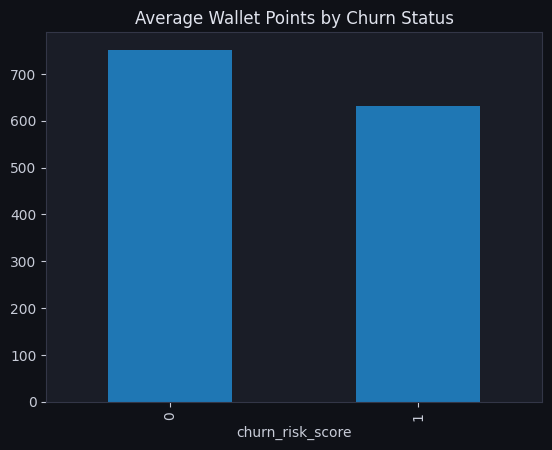

In [113]:
#To actually confirm the direction affecting churn based on points_in_wallet, we need to plot it directly. #Let's try something like:
import matplotlib.pyplot as plt

df_check = pd.read_csv('churn.csv')
df_check.groupby('churn_risk_score')['points_in_wallet'].mean().plot(kind='bar')
plt.title('Average Wallet Points by Churn Status')
plt.show()

As we can see, customers who stayed have more points on average than customers who left.

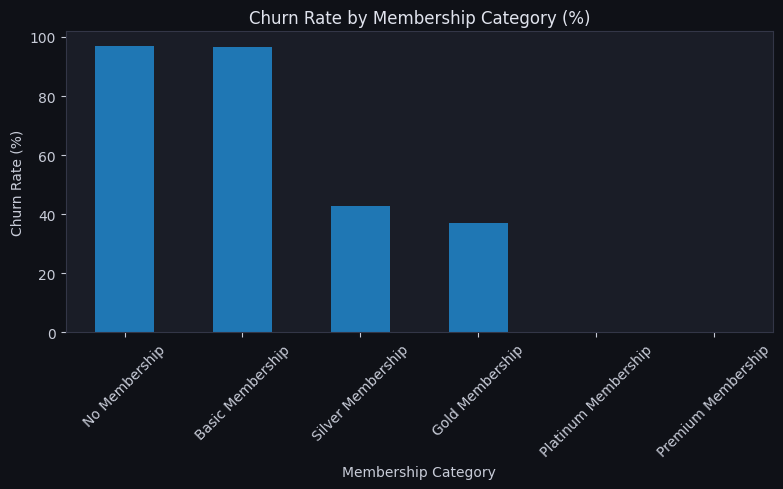

In [114]:

#Since membership_category is a categorical column (not numeric like points_in_wallet), i can't just take the mean. Instead i want to see the churn rate per membership category.

churn_by_membership = df_check.groupby('membership_category')['churn_risk_score'].mean() * 100
churn_by_membership = churn_by_membership.sort_values(ascending=False)

churn_by_membership.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Rate by Membership Category (%)')
plt.xlabel('Membership Category')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Churn rate drops dramatically as membership tier increases. No Membership (90%) and Basic Membership (95%) customers churn the most, while Premium membership customers are almost completely loyal.

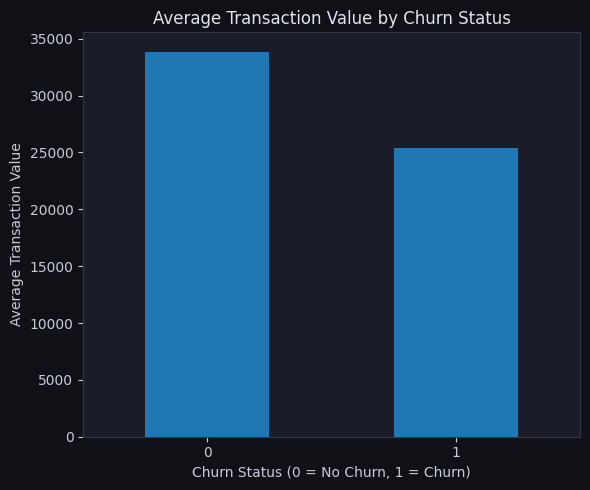

In [115]:

#To actually confirm the direction affecting churn based on points_in_wallet, we need to plot it directly. #Let's try something like:

df_check.groupby('churn_risk_score')['avg_transaction_value'].mean().plot(kind='bar', figsize=(6, 5))
plt.title('Average Transaction Value by Churn Status')
plt.xlabel('Churn Status (0 = No Churn, 1 = Churn)')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

As we can see, customers with lower average transaction value are more likely to leave.

##Key Findings
**Model Selection:**
XGBoost was selected as the best model because it achieves the highest F1 Score (93.98%), Accuracy (93.45%), and Precision (93.37%). Although Random Forest has a marginally higher Recall (94.88% vs 94.60%), the 0.28% difference is negligible. For churn prediction, F1 and overall consistency across metrics matter more because missing a true churner is more costly to the business than a false alarm.

**Top Churn Drivers:**

**points_in_wallet —** By far the strongest predictor. Customers with low wallet points are most likely to churn.

**membership_category —** The type of membership a customer holds significantly influences churn risk.

**avg_transaction_value —** Customers with lower average spend are more likely to leave.

**feedback —** Negative feedback strongly correlates with churn.

**avg_frequency_login_days —** Less frequent users are at higher churn risk.